# CSE 144 Final Project: Transfer Learning with DINOv2 ViT-B/14
**Toranosuke Matsuda**

Two-Stage Fine-Tuning with Vision Transformer:
- Stage 1: Freeze transformer encoder, train classification head only
- Stage 2: Unfreeze all layers, fine-tune end-to-end at low LR

In [30]:
# !pip install torch torchvision matplotlib tqdm scikit-learn pandas

**Imports and Device Setup**

Imports all required libraries (torch, torchvision, pandas, PIL, tqdm, etc.) and sets the compute device MPS for Apple Silicon, CUDA for Nvidia GPU, CPU as fallback.

In [31]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Dataset

print('torch:', torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('device:', device)


torch: 2.12.0
device: mps


**Reproducibility**

Defines and calls set_seed(42). Seeds Python, NumPy, and PyTorch's random number generators so training results are reproducible across runs.

In [32]:
def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print('Warning:', e)

set_seed(42)


## 1. Config

Key differences from EfficientNet using DINOv2 ViT:
- `S2_LR = 5e-5` (lower — ViT transformer weights are more sensitive)
- `BATCH_SIZE = 16` (ViT-B/16 has 86M params; drop to 16 if MPS runs out of memory)

All hyperparameters in one place: paths to data and checkpoints, NUM_CLASSES, IMG_SIZE, BATCH_SIZE, NUM_WORKERS, learning rates, epoch counts for both stages, and ImageNet normalization constants. This is the only cell you need to edit when tuning.

In [33]:
TRAIN_DIR = Path('./train')
TEST_DIR  = Path('./test')
CKPT_DIR  = Path('./checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 100
IMG_SIZE    = 224    # ViT-B/16 native input size
BATCH_SIZE  = 32     # inc from 16 for more GPU memory to make epochs more efficient ViT is much larger than EfficientNet
NUM_WORKERS = 0 # MPS for now doesn't support num_workers > 0, and implement parallel data loading if necessary

# Stage 1: transformer encoder frozen, head only
S1_EPOCHS = 15
S1_LR     = 1e-3

# Stage 2: all layers unfrozen
# 5e-5 instead of 1e-4 -- ViT weights are more sensitive to large updates
S2_EPOCHS = 20
S2_LR     = 1e-5 # was 5e-5; need more conservative LR for DINOv2

N_AUGMENTS = 16

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


## 2. Data Pipeline

Defines train and val transforms, loads the dataset, performs an 80/20 train/val split with random_split, wraps the val subset in TransformSubset to apply clean val transforms without augmentation, and creates the DataLoaders.

In [34]:
from torchvision.datasets import ImageFolder

# Strong augmentation to fight overfitting on 10 imgs/class
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),   # must be after ToTensor
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ImageFolder: folders '0','1',...,'99' -> alphabetical == numeric == correct label order
#full_train = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_tf)

class NumericImageFolder(ImageFolder):
    def find_classes(self, directory):
        classes = sorted(
            [d.name for d in os.scandir(directory) if d.is_dir()],
            key=lambda x: int(x)   # numeric sort: 0,1,2,...,10,11 not 0,1,10,11,2
        )
        class_to_idx = {cls: int(cls) for cls in classes}
        return classes, class_to_idx

full_train = NumericImageFolder(root=str(TRAIN_DIR), transform=train_tf)

print(dict(list(full_train.class_to_idx.items())[:15]))
# Must print: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14}

print('Total training samples :', len(full_train))
print('Classes detected       :', len(full_train.classes))
print('First 5 class->idx     :', dict(list(full_train.class_to_idx.items())[:5]))

n_total = len(full_train)
n_val   = max(1, int(0.2 * n_total))
n_train = n_total - n_val

train_set, val_set = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

class TransformSubset(Dataset):
    """Re-apply a different transform to a random_split Subset."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        real_idx    = self.subset.indices[idx]
        path, label = self.subset.dataset.samples[real_idx]
        img         = Image.open(path).convert('RGB')
        return self.transform(img), label

val_set_clean = TransformSubset(val_set, val_tf)

train_loader = DataLoader(train_set,     batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_set_clean, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train: {n_train} | Val: {n_val}')


{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14}
Total training samples : 1079
Classes detected       : 100
First 5 class->idx     : {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Train: 864 | Val: 215


## 3. Model: DINOv2 ViT-B/14 with Custom Head

ViT splits the image into 16×16 patches, treats each as a token, and uses
attention across all patches to build a global understanding of the image.
This gives it stronger generalization than CNNs on diverse class distributions.

Key structural differences from EfficientNet:
- Backbone is `model.encoder` (transformer blocks), not `model.features`
- Head is `model.heads.head`, not `model.classifier`
- Hidden size is 768 (vs 1280 for EfficientNet-B0)

Defines build_model() which loads pretrained DINOv2 ViT-B/14 from torch.hub, freezes the entire backbone, and replaces model.head (which defaults to nn.Identity) with a new Dropout(0.5) + Linear(768, 100) head. Uses model.embed_dim instead of model.head.in_features since the default head has no in_features attribute. Prints trainable vs total parameter counts.

In [35]:

'''
def build_model(num_classes=NUM_CLASSES, freeze_backbone=True):
    """
    Load pretrained ViT-B/16 and swap in a 100-class head.
    freeze_backbone=True  -> Stage 1 (head only trainable)
    freeze_backbone=False -> Stage 2 (all layers trainable)
    """
    weights = models.ViT_B_16_Weights.IMAGENET1K_V1
    model   = models.vit_b_16(weights=weights)

    # Freeze / unfreeze the transformer encoder blocks
    for param in model.encoder.parameters():
        param.requires_grad = not freeze_backbone

    # Also freeze the patch embedding in Stage 1
    for param in model.conv_proj.parameters():
        param.requires_grad = not freeze_backbone

    # Replace classification head: Linear(768, 1000) -> Linear(768, 100)
    in_features = model.heads.head.in_features  # 768
    model.heads.head = nn.Linear(in_features, num_classes)

    # Head is always trainable
    for param in model.heads.parameters():
        param.requires_grad = True

    return model.to(device)


model     = build_model(freeze_backbone=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')
print(f'Total params: {total/1e6:.1f}M  (ViT-B/16 is ~86M vs EfficientNet-B0 ~5M)')

'''

def build_model(freeze_backbone=True):
    """
    Load pretrained DINOv2 ViT-B/14 and attach a 100-class head.
    freeze_backbone=True  -> Stage 1 (head only)
    freeze_backbone=False -> Stage 2 (all layers)
    """
    model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

    # Freeze entire backbone first
    for param in model.parameters():
        param.requires_grad = False

    # Replace head -- DINOv2 exposes model.head
    # embed_dim is 768 for ViT-B/14 -- don't use model.head.in_features
    # because model.head is nn.Identity() by default, not a Linear laye
    #in_features = model.head.in_features  # 768
    in_features = model.embed_dim
    model.head = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, NUM_CLASSES),
    )

    # Head always trainable
    for param in model.head.parameters():
        param.requires_grad = True

    # Unfreeze backbone if Stage 2
    if not freeze_backbone:
        for param in model.parameters():
            param.requires_grad = True

    return model.to(device)


model     = build_model(freeze_backbone=True)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')


Using cache found in /Users/toras/.cache/torch/hub/facebookresearch_dinov2_main


Trainable: 76,900 / 86,657,380  (0.1%)


## 4. Training Util

Defines three functions used by both stages. train_one_epoch runs one full pass over the training set with gradient clipping (max_norm=1.0) to prevent the NaN explosion that happened with DINOv2. evaluate runs inference over the val set with no gradient computation. run_training_stage is the main training loop, and handles the optimizer, cosine annealing scheduler, per-epoch logging, and saves the best checkpoint whenever val acc improves.

In [36]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for images, targets in tqdm(loader, leave=False):
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, targets)
        
        if torch.isnan(loss):
            print("NaN loss detected: stopping epoch early")
            break
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # clips gradients norm at 1.0 to prevent explosion
        optimizer.step()
        total_loss    += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss   = criterion(logits, targets)
        total_loss    += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples


def run_training_stage(model, train_loader, val_loader, epochs, lr, ckpt_path, stage_name, history=None):
    """
    Generic loop for both stages.
    If val_acc is still rising at the last epoch, raise the epoch count
    in the config cell and re-run just this stage.
    """
    if history is None:
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # label_smoothing=0.1 prevents overconfident predictions on training data
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4   # L2 regularization -- penalizes large weights
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc, best_epoch = 0.0, -1

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        is_best = val_acc > best_val_acc
        print(
            f'[{stage_name}] Epoch {epoch:02d}/{epochs} | '
            f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}'
            + ('  <- best' if is_best else '')
        )

        if is_best:
            best_val_acc = val_acc
            best_epoch   = epoch
            torch.save(
                {'model_state_dict': model.state_dict(), 'epoch': epoch, 'val_acc': val_acc},
                ckpt_path
            )

    print(f'[{stage_name}] Best val acc: {best_val_acc:.4f} at epoch {best_epoch}')
    print(f'  -> If val acc was still rising at epoch {epochs}, consider increasing the epoch count.')
    return history, best_val_acc


## 5. Stage 1: Train Head Only (transformer encoder frozen)

Calls set_seed(42), builds a fresh frozen model, and runs run_training_stage for S1_EPOCHS epochs at S1_LR = 1e-3. Only the classification head trains here and the DINOv2 backbone stays frozen. Saves the best checkpoint to best_stage1_dino.pt

In [37]:
set_seed(42)
model   = build_model(freeze_backbone=True)
ckpt_s1 = str(CKPT_DIR / 'best_stage1_dino.pt')

history, s1_best = run_training_stage(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = S1_EPOCHS,
    lr           = S1_LR,
    ckpt_path    = ckpt_s1,
    stage_name   = 'Stage 1',
)


Using cache found in /Users/toras/.cache/torch/hub/facebookresearch_dinov2_main


[Stage 1] Epoch 01/15 | Train Loss: 4.2025  Train Acc: 0.1771 | Val Loss: 2.4324  Val Acc: 0.5116  <- best


[Stage 1] Epoch 02/15 | Train Loss: 2.4148  Train Acc: 0.5162 | Val Loss: 1.7755  Val Acc: 0.6512  <- best


[Stage 1] Epoch 03/15 | Train Loss: 1.9727  Train Acc: 0.6296 | Val Loss: 1.6546  Val Acc: 0.7116  <- best


[Stage 1] Epoch 04/15 | Train Loss: 1.7942  Train Acc: 0.6817 | Val Loss: 1.6594  Val Acc: 0.6837


...

[Stage 1] Epoch 11/15 | Train Loss: 1.4378  Train Acc: 0.8125 | Val Loss: 1.4585  Val Acc: 0.7674


[Stage 1] Epoch 12/15 | Train Loss: 1.4411  Train Acc: 0.8148 | Val Loss: 1.4615  Val Acc: 0.7674


[Stage 1] Epoch 13/15 | Train Loss: 1.4186  Train Acc: 0.8229 | Val Loss: 1.4613  Val Acc: 0.7581


[Stage 1] Epoch 14/15 | Train Loss: 1.4361  Train Acc: 0.8009 | Val Loss: 1.4554  Val Acc: 0.7581


[Stage 1] Epoch 15/15 | Train Loss: 1.4349  Train Acc: 0.8183 | Val Loss: 1.4544  Val Acc: 0.7581
[Stage 1] Best val acc: 0.7674 at epoch 8
  -> If val acc was still rising at epoch 15, consider increasing the epoch count.


## 6. Stage 2: Full Fine-Tune (all layers unfrozen)

Loads the best Stage 1 checkpoint, unfreezes all parameters, and runs a full end-to-end fine-tune at S2_LR = 1e-5, lower than Stage 1 to protect the pretrained DINOv2 weights. Gradient clipping in train_one_epoch prevents the NaN collapse. Appends to the same history dict so the training curves show both stages together. Saves best checkpoint to best_stage2_dino.pt

In [38]:

'''
# Load best Stage 1 weights, then unfreeze everything
ckpt = torch.load(ckpt_s1, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded Stage 1 checkpoint (epoch {ckpt['epoch']}, val_acc {ckpt['val_acc']:.4f})")

for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')

ckpt_s2 = str(CKPT_DIR / 'best_stage2_vit.pt')

history, s2_best = run_training_stage(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = S2_EPOCHS,
    lr           = S2_LR,
    ckpt_path    = ckpt_s2,
    stage_name   = 'Stage 2',
    history      = history,
)
'''

# Load best Stage 1 weights
ckpt = torch.load(ckpt_s1, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
# print(f"Loaded Stage 1 checkpoint (epoch {ckpt['epoch']}, val_acc {ckpt['val_acc']:.4f})")
print(f"Reloaded Stage 1: val_acc {ckpt['val_acc']:.4f}")


# unfreeze everything
for param in model.parameters():
    param.requires_grad = True

# gradual unfreezing with DINOv2 too aggressive with gradient explosion and and collapses model

'''

# ── Gradual unfreezing ─────────────────────────────────────────────────────
# DINOv2 ViT-B/14 has 12 transformer blocks (indices 0-11)
# Unfreeze from top (block 11, closest to head) down to bottom (block 0)
# 3 epochs per block lets each layer adapt before the next one opens

EPOCHS_PER_BLOCK = 3
GRADUAL_LR       = 2e-5
criterion        = nn.CrossEntropyLoss(label_smoothing=0.1)

best_val_acc = 0.0
ckpt_s2      = str(CKPT_DIR / 'best_stage2_dino.pt')

if history is None:
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for block_idx in range(11, -1, -1):
    # Unfreeze this transformer block
    for param in model.blocks[block_idx].parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nUnfroze block {block_idx} — trainable params: {trainable:,}")

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=GRADUAL_LR,
        weight_decay=1e-4
    )

    for epoch in range(1, EPOCHS_PER_BLOCK + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        is_best = val_acc > best_val_acc
        print(f"  Epoch {epoch}/{EPOCHS_PER_BLOCK} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
              + ("  <- best" if is_best else ""))

        if is_best:
            best_val_acc = val_acc
            torch.save({'model_state_dict': model.state_dict(),
                        'epoch': epoch, 'val_acc': val_acc}, ckpt_s2)
                        
'''

# ── Final full fine-tune pass after all blocks are unfrozen ────────────────
print("\nStarting final full fine-tune pass...")
history, s2_best = run_training_stage(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = S2_EPOCHS,
    lr           = S2_LR,
    ckpt_path    = str(CKPT_DIR / 'best_stage2_dino.pt'), # ckpt_s2/1
    stage_name   = 'Stage 2 Full',
    history      = history,
)


Reloaded Stage 1: val_acc 0.7674

Starting final full fine-tune pass...


[Stage 2 Full] Epoch 01/20 | Train Loss: 1.6599  Train Acc: 0.7465 | Val Loss: 1.4955  Val Acc: 0.7349  <- best


[Stage 2 Full] Epoch 02/20 | Train Loss: 1.4939  Train Acc: 0.7882 | Val Loss: 1.4640  Val Acc: 0.7581  <- best


[Stage 2 Full] Epoch 03/20 | Train Loss: 1.4187  Train Acc: 0.8125 | Val Loss: 1.4101  Val Acc: 0.7953  <- best


[Stage 2 Full] Epoch 04/20 | Train Loss: 1.3442  Train Acc: 0.8438 | Val Loss: 1.4150  Val Acc: 0.7907


...

[Stage 2 Full] Epoch 16/20 | Train Loss: 1.0216  Train Acc: 0.9757 | Val Loss: 1.3279  Val Acc: 0.8279  <- best


[Stage 2 Full] Epoch 17/20 | Train Loss: 1.0169  Train Acc: 0.9780 | Val Loss: 1.3313  Val Acc: 0.8419  <- best


[Stage 2 Full] Epoch 18/20 | Train Loss: 1.0227  Train Acc: 0.9769 | Val Loss: 1.3313  Val Acc: 0.8233


[Stage 2 Full] Epoch 19/20 | Train Loss: 1.0174  Train Acc: 0.9745 | Val Loss: 1.3312  Val Acc: 0.8186


[Stage 2 Full] Epoch 20/20 | Train Loss: 1.0133  Train Acc: 0.9757 | Val Loss: 1.3312  Val Acc: 0.8186
[Stage 2 Full] Best val acc: 0.8419 at epoch 17
  -> If val acc was still rising at epoch 20, consider increasing the epoch count.


## 7. Training Curves

Plots loss and accuracy for both stages on the same axes, with a dashed vertical line at the Stage 1/Stage 2 boundary and shaded background regions. Saves training_curves_dino.png

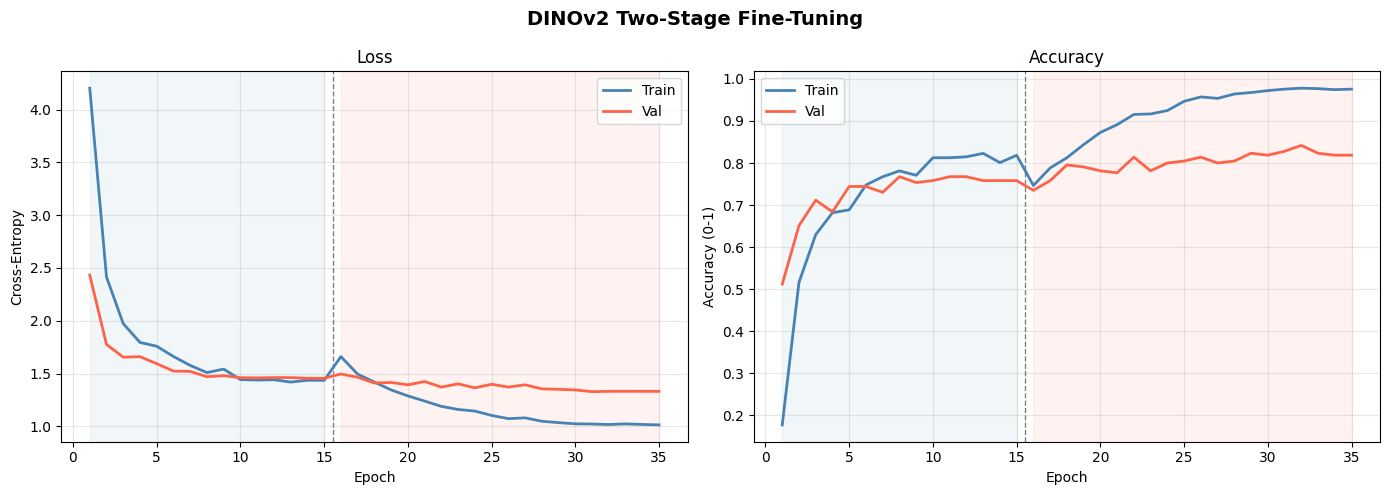

Saved training_curves_vit.png


In [39]:
total_epochs = S1_EPOCHS + S2_EPOCHS
epochs_range = range(1, total_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DINOv2 Two-Stage Fine-Tuning', fontsize=14, fontweight='bold')

for ax in (ax1, ax2):
    ax.axvspan(1,             S1_EPOCHS,    alpha=0.07, color='steelblue')
    ax.axvspan(S1_EPOCHS + 1, total_epochs, alpha=0.07, color='tomato')
    ax.axvline(x=S1_EPOCHS + 0.5, color='gray', linestyle='--', linewidth=1)

ax1.plot(epochs_range, history['train_loss'], label='Train', color='steelblue', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   label='Val',   color='tomato',    linewidth=2)
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='Train', color='steelblue', linewidth=2)
ax2.plot(epochs_range, history['val_acc'],   label='Val',   color='tomato',    linewidth=2)
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (0-1)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_vit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves_vit.png')


## 8. Load Best Model & Final Validation

Loads the best Stage 2 checkpoint and runs evaluate one final time on the val set to confirm the reported accuracy matches what was saved.

In [40]:
ckpt = torch.load(str(CKPT_DIR / 'best_stage2_dino.pt'), map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best model: epoch {ckpt['epoch']}, val_acc {ckpt['val_acc']:.4f}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
val_loss, val_acc = evaluate(model, val_loader, criterion)
print(f'Final val loss: {val_loss:.4f} | Final val acc: {val_acc:.4f}')

Loaded best model: epoch 17, val_acc 0.8419
Final val loss: 1.3313 | Final val acc: 0.8419


## 9. Generate submission.csv with TTA

Loads the DINOv2 checkpoint and globs the test folder numerically to get all 1036 image IDs. Runs predict_with_tta which for each test image runs N_AUGMENTS=16 augmented forward passes through both models simultaneously, sums all logits, and takes argmax. Writes submission.csv with 1036 rows.

Test Time Augmentation (TTA): run each test image through the model multiple times
with random augmentations, then average the logits before taking argmax.

In [41]:

'''
# Load canonical ID order from sample_submission.csv
#sample_df = pd.read_csv('sample_submission.csv')
#print(f'Expected rows: {len(sample_df)}')
#assert len(sample_df) == 1000, f'Expected 1000, got {len(sample_df)}'

# Get IDs directly from the test folder -- ground truth of what Kaggle expects
test_images = sorted(
    [f.name for f in Path(TEST_DIR).glob("*.jpg")],
    key=lambda x: int(x.split(".")[0])   # numeric sort: 0, 1, 2, ..., 1035
)
print(f"Test images found: {len(test_images)}")  # should print 1036


# TTA transform -- same augmentations as training
tta_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

N_AUGMENTS = 8   # number of TTA passes per image -- higher = better but slower


@torch.no_grad()
def predict_with_tta(model, image_ids, test_dir, n_augments=N_AUGMENTS):
    """
    For each test image, run n_augments forward passes with random augmentations
    and average the logits. More robust than a single deterministic prediction.
    """
    model.eval()
    all_preds = []

    for fname in tqdm(image_ids, desc='TTA Inference'):
        img        = Image.open(Path(test_dir) / fname).convert('RGB')
        logits_sum = torch.zeros(NUM_CLASSES).to(device)

        for _ in range(n_augments):
            tensor     = tta_tf(img).unsqueeze(0).to(device)  # (1, 3, 224, 224)
            logits_sum += model(tensor).squeeze(0)             # accumulate raw logits

        all_preds.append(logits_sum.argmax().item())           # majority vote via averaged logits

    return all_preds


#all_labels = predict_with_tta(model, sample_df['ID'].tolist(), TEST_DIR)
all_labels = predict_with_tta(model, test_images, TEST_DIR)
submission = pd.DataFrame({'ID': test_images, 'Label': all_labels})

#submission = pd.DataFrame({'ID': sample_df['ID'].tolist(), 'Label': all_labels})
submission.to_csv('submission.csv', index=False)
print('submission.csv written -- first 10 rows:')
print(submission.head(10))
'''

# ── Load DINOv2 (primary model) ────────────────────────────────────────────
ckpt_dino = torch.load(str(CKPT_DIR / 'best_stage2_dino.pt'), map_location=device)
model.load_state_dict(ckpt_dino['model_state_dict'])
model.eval()
print(f"Loaded DINOv2 checkpoint: val_acc {ckpt_dino['val_acc']:.4f}")

# ── TTA transform ──────────────────────────────────────────────────────────
tta_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

N_AUGMENTS = 16   # more passes = more robust predictions

# ── TTA inference ─────────────────────────────────────────────────
# For each test image: run N_AUGMENTS passes through BOTH models,
# sum all logits together, take argmax -- different architectures
# make different errors so averaging them reduces variance

@torch.no_grad()
def predict_with_tta(model, image_ids, test_dir, n_augments=N_AUGMENTS):
    model.eval()
    all_preds = []

    for fname in tqdm(image_ids, desc='TTA Inference'):
        img        = Image.open(Path(test_dir) / fname).convert('RGB')
        logits_sum = torch.zeros(NUM_CLASSES).to(device)

        for _ in range(n_augments):
            tensor = tta_tf(img).unsqueeze(0).to(device)
            logits_sum += model(tensor).squeeze(0)   # accumulate across models and passes

        all_preds.append(logits_sum.argmax().item())

    return all_preds


# Get test image IDs
test_images = sorted(
    [f.name for f in Path(TEST_DIR).glob("*.jpg")],
    key=lambda x: int(x.split(".")[0])
)
print(f"Test images: {len(test_images)}")

all_labels = predict_with_tta(model, test_images, TEST_DIR)

submission = pd.DataFrame({'ID': test_images, 'Label': all_labels})
submission.to_csv('submission.csv', index=False)
print(f"submission.csv written — {len(submission)} rows")
print(submission.head(10))


Loaded DINOv2 checkpoint: val_acc 0.8419
Test images: 1036


TTA Inference: 100%|██████████| 1036/1036 [04:31<00:00,  3.82it/s]

submission.csv written — 1036 rows
      ID  Label
0  0.jpg     62
1  1.jpg     43
2  2.jpg     38
3  3.jpg     51
4  4.jpg     42
5  5.jpg     89
6  6.jpg      3
7  7.jpg     28
8  8.jpg     71
9  9.jpg     65


## 10. Sanity Checks

Asserts that submission.csv has exactly 1036 rows, correct column names (ID, Label), all labels between 0 and 99, and prints how many unique classes were predicted.

In [42]:
#assert len(submission) == 1000,                               f'Expected 1000 rows, got {len(submission)}'
assert list(submission.columns) == ['ID', 'Label'],          'Wrong column names'
assert submission['Label'].between(0, 99).all(),              'Labels out of 0-99 range'
#assert submission['ID'].tolist() == sample_df['ID'].tolist(), 'ID order does not match sample_submission.csv'

print('All checks passed. Ready to submit to Kaggle.')
print(f"Unique classes predicted: {submission['Label'].nunique()} / 100")
print(submission['Label'].value_counts().head(10))


All checks passed. Ready to submit to Kaggle.
Unique classes predicted: 100 / 100
Label
12    19
52    18
91    18
78    17
97    15
66    15
62    14
65    14
86    14
93    14
Name: count, dtype: int64


In [43]:
test_images = sorted(
    [f.name for f in Path(TEST_DIR).glob("*.jpg")],
    key=lambda x: int(x.split(".")[0])
)
print(f"Total test images: {len(test_images)}")
print(f"First 5: {test_images[:5]}")
print(f"Last 5:  {test_images[-5:]}")

Total test images: 1036
First 5: ['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg']
Last 5:  ['1031.jpg', '1032.jpg', '1033.jpg', '1034.jpg', '1035.jpg']
